# Hypothesis Testing — Churn Prediction

In this notebook we test **15 hypotheses** about what makes a customer churn.
Each hypothesis follows the same simple pattern:

1. State what we think is happening (the hypothesis)
2. Pick the right statistical test for the type of data
3. Run the test
4. Read the result and say what it means in plain English

**What is a p-value?**  
A p-value tells us the probability that we would see this result just by chance.  
- p < 0.05 → the result is statistically significant (very unlikely to be random)
- p ≥ 0.05 → we cannot confidently reject the null hypothesis

**Tests used:**
- **Chi-Square test** — checks if two categorical things (e.g. band vs churn) are related
- **T-test** — checks if the average of something (e.g. tenure years) differs between two groups
- **Mann-Whitney U test** — like a t-test but works even when data is not normally distributed
- **Point-Biserial Correlation** — measures how strongly a numeric feature is linearly related to churn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, pointbiserialr

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

In [5]:
# Load the merged dataset
df = pd.read_csv('../../data/merged/merged.csv', low_memory=False)

# Create the churn column (1 = churned, 0 = stayed)
df['churn'] = (df['prospect_outcome'] == 'Churned').astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Total customers: {len(df):,}')
print(f'Churned: {df["churn"].sum():,} ({df["churn"].mean():.1%})')
print(f'Retained: {(df["churn"]==0).sum():,} ({(1-df["churn"].mean()):.1%})')

Dataset shape: (54478, 140)
Total customers: 54,478
Churned: 2,994 (5.5%)
Retained: 51,484 (94.5%)


---
## H1 — Customers who expressed desire to cancel churn more

**Hypothesis:** Customers who said they wanted to cancel on a renewal call will churn at a higher rate than those who did not.  
**Test:** Chi-Square — desire_to_cancel_clean and churn variables are categorical 

**Null hypothesis:** There is no relationship between expressing desire to cancel and actually churning.

In [6]:
#Filter data
h1_data = df.dropna(subset=['desire_to_cancel_clean'])
churn_rates = h1_data.groupby('desire_to_cancel_clean')['churn'].mean().sort_values(ascending=False)

#chi2 Test
contingency = pd.crosstab(h1_data['desire_to_cancel_clean'], h1_data['churn'])
chi2, p_val, *_ = chi2_contingency(contingency)

print("chi2 Value:",chi2)
print("P-value:",p_val)

if p_val < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between desire to cancel and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between desire to cancel and churn.")


chi2 Value: 5080.004653319464
P-value: 0.0
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between desire to cancel and churn.


---
## H2 — Newer customers churn more than long-term customers

**Hypothesis:** Customers in their first year have not built enough loyalty yet, so they leave at a higher rate.  
**Test:** T-test — compare average tenure years between churned and retained groups.  
**Null hypothesis:** There is no difference in average tenure between churned and retained customers.

Average tenure — Churned group:  4.17 years
Average tenure — Retained group: 7.00 years
T-statistic: -27.641487910450557
P-value: 5.0560612050869966e-167
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant difference in tenure between churned and retained customers.


NameError: name 'tg' is not defined

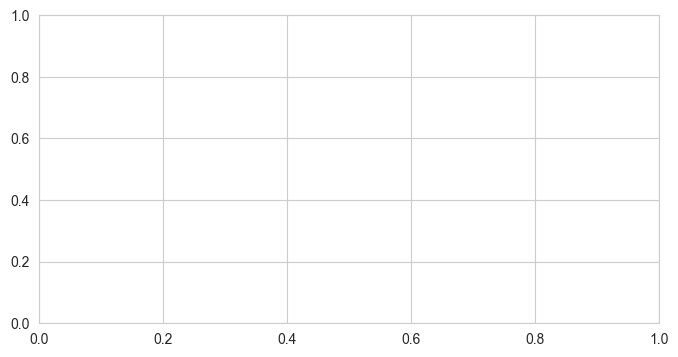

In [8]:
churned_tenure   = df[df['churn'] == 1]['tenure_years'].dropna()
retained_tenure  = df[df['churn'] == 0]['tenure_years'].dropna()

t_stat, p_value = ttest_ind(churned_tenure, retained_tenure)

print(f'Average tenure — Churned group:  {churned_tenure.mean():.2f} years')
print(f'Average tenure — Retained group: {retained_tenure.mean():.2f} years')

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant difference in tenure between churned and retained customers.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant difference in tenure between churned and retained customers.")

fig, ax = plt.subplots(figsize=(8, 4))
tg.plot(kind='bar', ax=ax)
ax.set_title('H2: Churn Rate by Tenure Group')
ax.set_xlabel('Tenure Group (years)')
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## H3 — Customers with Status Score = 0 churn at a much higher rate

**Hypothesis:** A status score of 0 means the customer has no active accreditation, so the membership feels worthless to them — they are much more likely to leave.  
**Test:** Chi-Square — status_score (0 vs non-zero) vs churn (0/1).  
**Null hypothesis:** Status score = 0 has no effect on churn.

In [9]:
# Create a simple flag: 1 if status score is 0, else 0
df['status_zero'] = (df['status_scores'] == 0).astype(int)

contingency = pd.crosstab(df['status_zero'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

print("chi2 Value:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between having a zero status score and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between having a zero status score and churn.")


chi2 Value: 24394.32451524963
P-value: 0.0
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between having a zero status score and churn.


---
## H4 — Customers who mentioned financial hardship are more likely to churn

**Hypothesis:** Customers who mentioned financial difficulty in email interactions cannot afford the renewal and will leave.  
**Test:** Chi-Square — financial_hardship_mentioned (Yes/No) vs churn.  
**Null hypothesis:** Mentioning financial hardship has no relationship with churn.

Chi-Square Value: 1707.8446356736777
P-value: 0.0
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between financial hardship mention and churn.


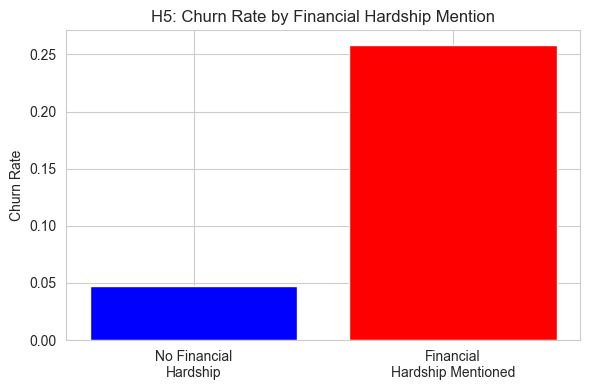

In [10]:
df['hardship_flag'] = df['crm_financial_hardship_mentioned'].astype(str).str.strip().isin(['Yes']).astype(int) #handling trailing space

contingency = pd.crosstab(df['hardship_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

rates = df.groupby('hardship_flag')['churn'].mean()

print("Chi-Square Value:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between financial hardship mention and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between financial hardship mention and churn.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Financial\nHardship', 'Financial\nHardship Mentioned'],
       rates.values, color=['blue', 'red'])
ax.set_title('H5: Churn Rate by Financial Hardship Mention')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

---
## H5 — Customers who requested a discount are more likely to churn

**Hypothesis:** Asking for a discount signals price sensitivity. Customers who ask for a discount but do not get one (or feel the price is still too high) are more likely to leave.  
**Test:** Chi-Square — discount_requested_flag (1/0) vs churn.  
**Null hypothesis:** Requesting a discount has no relationship with churn.

chi2 Value: 0.12175440407807894
P-value: 0.7271394317983686
Result: NOT SIGNIFICANT (p >= 0.05)
Fail to reject H0: There is no significant association between discount request and churn.


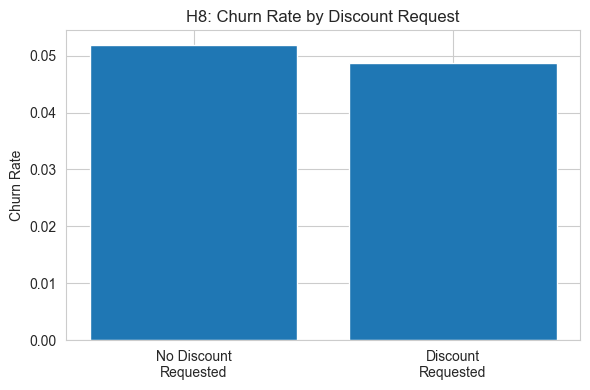

In [11]:
h8_data = df[df['discount_requested_flag'].notna()].copy()

contingency = pd.crosstab(h8_data['discount_requested_flag'], h8_data['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

rates = h8_data.groupby('discount_requested_flag')['churn'].mean()

print("chi2 Value:", chi2)
print("P-value:", p_value)


if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between discount request and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between discount request and churn.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Discount\nRequested', 'Discount\nRequested'],
       rates.values)
ax.set_title('H8: Churn Rate by Discount Request')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

---
## H6 — Customers with a dissatisfied CC sentiment are more likely to churn

**Hypothesis:** Customers who are marked as Dissatisfied during a customer care call have an unresolved issue. They are more likely to leave at renewal.  
**Test:** Chi-Square — cc_contractor_sentiment (Dissatisfied vs Satisfied/Neutral) vs churn.  
**Null hypothesis:** CC call sentiment has no relationship with churn.

chi2 Value: 18.655409979214852
P-value: 8.892608938437083e-05
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between CC call sentiment and churn.


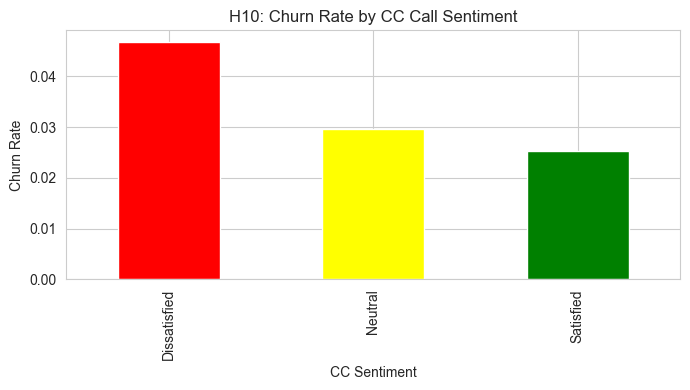

In [12]:
# Keep only the three clean sentiment values
h10_data = df[df['cc_contractor_sentiment'].isin(['Dissatisfied', 'Neutral', 'Satisfied'])].copy()

contingency = pd.crosstab(h10_data['cc_contractor_sentiment'], h10_data['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

rates = h10_data.groupby('cc_contractor_sentiment')['churn'].mean().sort_values(ascending=False)
print("chi2 Value:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between CC call sentiment and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between CC call sentiment and churn.")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['red', 'yellow', 'green']
rates.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('H10: Churn Rate by CC Call Sentiment')
ax.set_xlabel('CC Sentiment')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

---
## H7 — Customers who raised a serious complaint are more likely to churn

**Hypothesis:** A serious complaint indicates deep dissatisfaction. Even if the complaint is resolved, the bad experience may push the customer to leave at renewal.  
**Test:** Chi-Square — serious_complaint_flag (1/0) vs churn.  
**Null hypothesis:** Raising a serious complaint has no effect on churn.

Chi2_value: 45.37657734482371
P-value: 1.6256694854820622e-11
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between serious complaint and churn.


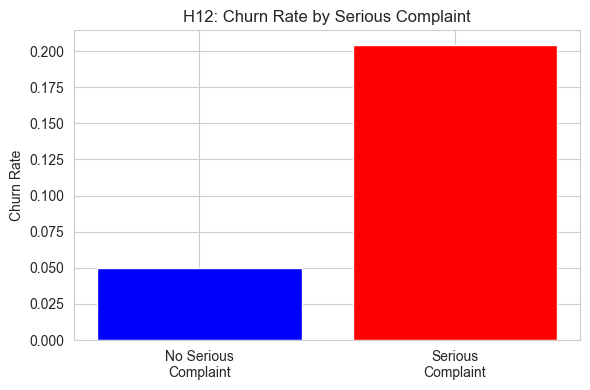

In [13]:
h12_data = df[df['serious_complaint_flag'].notna()].copy()

contingency = pd.crosstab(h12_data['serious_complaint_flag'], h12_data['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)
rates = h12_data.groupby('serious_complaint_flag')['churn'].mean()

print("Chi2_value:", chi2)
print("P-value:", p_value)
if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between serious complaint and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between serious complaint and churn.")    

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Serious\nComplaint', 'Serious\nComplaint'],rates.values, color=['blue', 'red'])
ax.set_title('H12: Churn Rate by Serious Complaint')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

---
## H8 — Customers the agent had to chase more often are more likely to churn

**Hypothesis:** If the agent had to chase a customer multiple times via email, it means the customer is not engaging. Low engagement at renewal time = higher churn risk.  
**Test:** Chi-Square — agent chase level (Low/Medium/High) vs churn.  
**Null hypothesis:** How often the agent had to chase the customer has no effect on churn.

Chi2 Value: 140.891108589937
P-value: 2.546152987910281e-31
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between agent chase count and churn.


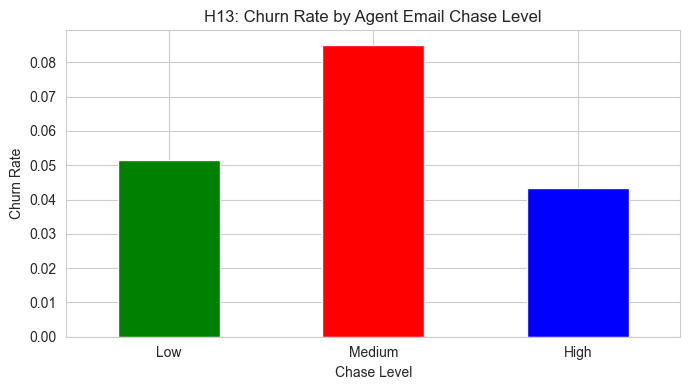

In [14]:
# crm_agent_chase_count is already categorised as Low / Medium / High
h13_data = df[df['crm_agent_chase_count'].isin(['Low', 'Medium', 'High'])].copy()

contingency = pd.crosstab(h13_data['crm_agent_chase_count'], h13_data['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

order = ['Low', 'Medium', 'High']
rates = h13_data.groupby('crm_agent_chase_count')['churn'].mean().reindex(order)

print("Chi2 Value:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between agent chase count and churn.") 
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between agent chase count and churn.")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['green', 'red', 'blue']
rates.plot(kind='bar', ax=ax, color=colors)
ax.set_title('H13: Churn Rate by Agent Email Chase Level')
ax.set_xlabel('Chase Level')
ax.set_ylabel('Churn Rate')

ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## H9 — Customers dissatisfied with renewal price in emails are more likely to churn

**Hypothesis:** When a customer explicitly says they are unhappy with the renewal price in an email, price is the main driver of their potential churn.  
**Test:** Chi-Square — crm_dissatisified_with_renewal_price (Yes/No) vs churn.  
**Null hypothesis:** Email-expressed price dissatisfaction has no effect on churn.

chi2 Value: 9.431242504341196
P-value: 0.0021331971045910987
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between price dissatisfaction and churn.


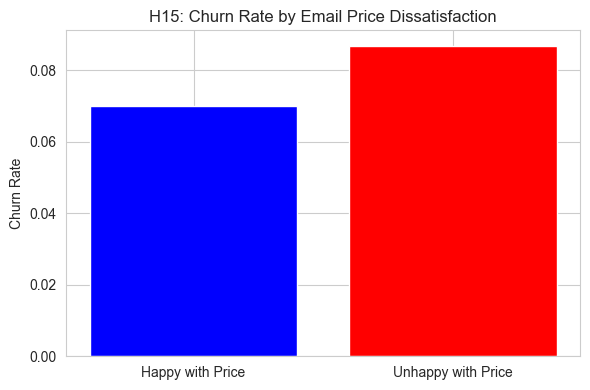

In [15]:
# Keep only Yes/No rows — ignore 'Not Discussed' and 'Unknown' for this test
h15_data = df[df['crm_dissatisified_with_renewal_price'].isin(['Yes', 'No'])].copy()

contingency = pd.crosstab(h15_data['crm_dissatisified_with_renewal_price'], h15_data['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)

rates = h15_data.groupby('crm_dissatisified_with_renewal_price')['churn'].mean()

print("chi2 Value:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between price dissatisfaction and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between price dissatisfaction and churn.")


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Happy with Price', 'Unhappy with Price'],
       [rates['No'], rates['Yes']], color=['blue', 'red'])
ax.set_title('H15: Churn Rate by Email Price Dissatisfaction')
ax.set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

## H10 — Customers who failed or have a suspended audit status churn more

**Hypothesis:** A customer whose accreditation audit has Failed or is Suspended
has a broken membership — it no longer provides value to them.
They are significantly more likely to leave at renewal than customers who are fully Accredited.

**Test:** Chi-Square — proforma_audit_status (Accredited / In Process / Failed / Suspended) vs churn.

**Null hypothesis:** Audit status has no relationship with whether a customer churns.

Contingency Table:
churn                      0     1
proforma_audit_status             
Accredited             35751  1197
Failed                  5854  1085
In Process              9316   672
Suspended                563    40

Chi-Square Value : 1766.6278
Degrees of Freedom: 3
P-value          : 0.000000

Result: SIGNIFICANT (p < 0.05)
Reject H0: Audit status has a significant association with churn.
Customers with Failed or Suspended accreditation churn at a higher rate.

Churn rates by audit status:
  Failed         : 15.6%
  In Process     : 6.7%
  Suspended      : 6.6%
  Accredited     : 3.2%


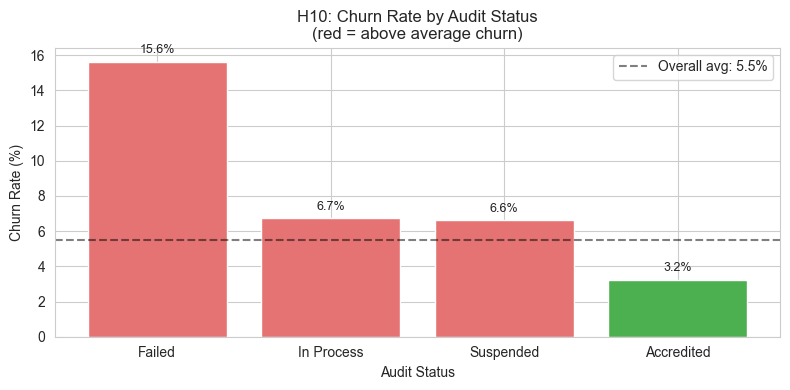

In [18]:
h16_data = df[df['proforma_audit_status'].isin([
    'Accredited', 'In Process', 'Failed', 'Suspended'
])].copy()

# Contingency table
contingency = pd.crosstab(h16_data['proforma_audit_status'], h16_data['churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Churn rate per audit status
rates = (
    h16_data.groupby('proforma_audit_status')['churn']
    .mean()
    .sort_values(ascending=False)
)

print("Contingency Table:")
print(contingency)
print()
print(f"Chi-Square Value : {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value          : {p_value:.6f}")
print()

if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05)")
    print("Reject H0: Audit status has a significant association with churn.")
    print("Customers with Failed or Suspended accreditation churn at a higher rate.")
else:
    print("Result: NOT SIGNIFICANT (p >= 0.05)")
    print("Fail to reject H0: No significant association between audit status and churn.")

print()
print("Churn rates by audit status:")
for status, rate in rates.items():
    print(f"  {status:15s}: {rate*100:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E57373' if r > df['churn'].mean() else '#4CAF50' for r in rates.values]
bars = ax.bar(rates.index, rates.values * 100, color=colors, edgecolor='white')
for bar, val in zip(bars, rates.values * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.axhline(df['churn'].mean() * 100, color='black', linestyle='--',
           alpha=0.5, label=f'Overall avg: {df["churn"].mean()*100:.1f}%')
ax.set_title('H10: Churn Rate by Audit Status\n(red = above average churn)')
ax.set_xlabel('Audit Status')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## H11 — Customers with more active client connections have a lower churn rate

**Hypothesis:** Each client connection is a reason for the customer to keep their
accreditation active — if they lose the membership, they lose access to work with
those clients. Customers with more connections face a higher switching cost and
are significantly less likely to churn.

**Test:** T-test — compare the mean number of current_anchorings
between churned and retained customers.

**Null hypothesis:** There is no difference in the average number of client connections
between customers who churn and those who stay.

Average connections — Churned  : 1.18
Average connections — Retained : 3.06
Difference                     : 1.88 more connections in retained group

T-statistic : -39.4960
P-value     : 0.000000

Result: SIGNIFICANT (p < 0.05)
Reject H0: Retained customers have significantly more client connections than churned customers.
More connections = higher switching cost = stronger retention.


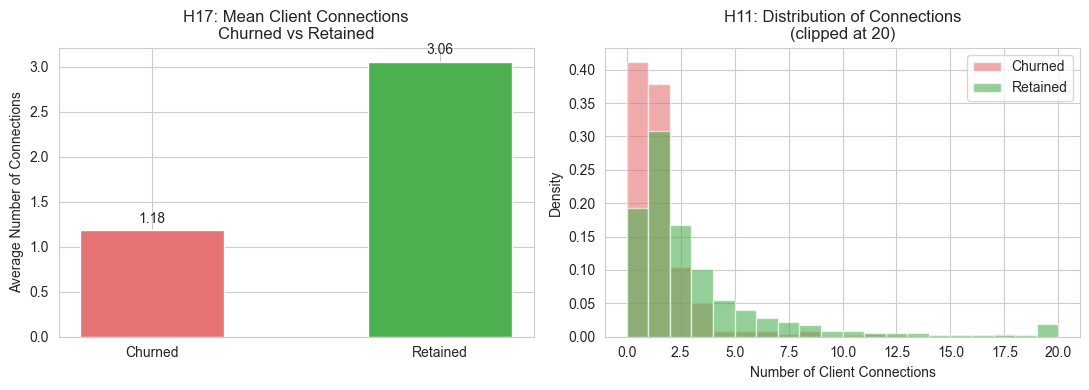

In [19]:

churned_conn  = df[df['churn'] == 1]['current_anchorings'].dropna()
retained_conn = df[df['churn'] == 0]['current_anchorings'].dropna()

t_stat, p_value = ttest_ind(churned_conn, retained_conn, equal_var=False)

print(f"Average connections — Churned  : {churned_conn.mean():.2f}")
print(f"Average connections — Retained : {retained_conn.mean():.2f}")
print(f"Difference                     : {retained_conn.mean() - churned_conn.mean():.2f} more connections in retained group")
print()
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print()

if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05)")
    print("Reject H0: Retained customers have significantly more client connections than churned customers.")
    print("More connections = higher switching cost = stronger retention.")
else:
    print("Result: NOT SIGNIFICANT (p >= 0.05)")
    print("Fail to reject H0: No significant difference in client connections between groups.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: mean comparison bar
means = [churned_conn.mean(), retained_conn.mean()]
axes[0].bar(['Churned', 'Retained'], means,
            color=['#E57373', '#4CAF50'], edgecolor='white', width=0.5)
for i, v in enumerate(means):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('H17: Mean Client Connections\nChurned vs Retained')
axes[0].set_ylabel('Average Number of Connections')

# Right: distribution comparison
axes[1].hist(churned_conn.clip(upper=20),  bins=20, alpha=0.6,
             color='#E57373', label='Churned',  density=True)
axes[1].hist(retained_conn.clip(upper=20), bins=20, alpha=0.6,
             color='#4CAF50', label='Retained', density=True)
axes[1].set_title('H11: Distribution of Connections\n(clipped at 20)')
axes[1].set_xlabel('Number of Client Connections')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()